# Module 5 Homework

## Cluster Analysis, K-Means, and Linear Discriminant Analysis

**Course:** MS3313  
**Module:** 5 — Clustering & Discriminant Analysis

---

### Instructions

This notebook contains **three questions**. For each question:

- Code cells already define the **dataset name**, **input variable name (X)**, and **output variable name (Y)** you must use. Do not rename them — graders look for these specific names.
- Wherever you see `# YOUR CODE HERE — delete this comment when you add your code`, replace that line with your solution.
- After each question, an **analysis answer** markdown cell is provided. Replace `*Your answer here*` with your written interpretation (3–6 sentences).

### Required variable names

| Question | Dataframe | Inputs (X) | Output / Target (Y) |
|----------|-----------|------------|--------------------|
| 1 | `pharma.df` | `X_pharma`, `X_pharma_norm` | `Y_pharma_cluster` |
| 2 | `admin.df` | `X_admin` | `Y_admin`, `Y_admin_pred` |
| 3 | `cereals_clean` | `X_cereals_norm` | `Y_cereals_cluster` |

---

## Setup: Load Required Libraries

Run this cell as-is. Do not modify.

In [1]:
suppressPackageStartupMessages({
  library(mlba)
  library(dplyr)
  library(ggplot2)
  library(tidyr)
  library(tibble)
  library(cluster)
  library(factoextra)
  library(MASS)
  library(IRdisplay)
})

set.seed(123)

---

## Question 1 — Hierarchical Cluster Analysis on Pharmaceutical Companies

**Dataset:** `mlba::Pharmaceuticals` (21 pharmaceutical firms × 14 variables)

**Inputs (X):** 9 numeric financial metrics — `Market_Cap`, `Beta`, `PE_Ratio`, `ROE`, `ROA`, `Asset_Turnover`, `Leverage`, `Rev_Growth`, `Net_Profit_Margin`

**Output (Y):** Cluster label assigned to each firm using **hierarchical clustering with Euclidean distance and average linkage**, cut at **k = 3** clusters.

**Tasks:**
1. Load the data and set `Symbol` as row names → store in `pharma.df`
2. Select the 9 numeric financial variables → store in `X_pharma`
3. **Standardize** the variables (z-score) → store in `X_pharma_norm`
4. Compute the Euclidean distance matrix → store in `d_pharma`
5. Perform hierarchical clustering with **average linkage** → store in `hc_pharma`
6. Plot the dendrogram (use `fviz_dend` with `k = 3`)
7. Cut the tree at **k = 3** → store the cluster labels in `Y_pharma_cluster`; report cluster sizes and members
8. Report the **cluster centroid profiles** (mean of each variable per cluster, on the original scale) → store in `pharma_profile`
9. Provide a written interpretation in the **markdown answer cell** at the end of this question

### Step 1 & 2 — Load Data and Select Inputs (X)

Use `pharma.df` as the dataframe and `X_pharma` for the 9 input variables.

In [2]:


pharma.df <- mlba::Pharmaceuticals |>
  column_to_rownames("Symbol")
X_pharma  <- pharma.df[, sapply(pharma.df, is.numeric)]

cat("Number of firms:", nrow(X_pharma), "\n")
cat("Number of input variables:", ncol(X_pharma), "\n")
head(X_pharma)

Number of firms: 21 
Number of input variables: 9 


,Market_Cap,Beta,PE_Ratio,ROE,ROA,Asset_Turnover,Leverage,Rev_Growth,Net_Profit_Margin
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ABT,68.44,0.32,24.7,26.4,11.8,0.7,0.42,7.54,16.1
AGN,7.58,0.41,82.5,12.9,5.5,0.9,0.60,9.16,5.5
AHM,6.30,0.46,20.7,14.9,7.8,0.9,0.27,7.05,11.2
AZN,67.63,0.52,21.5,27.4,15.4,0.9,0.00,15.00,18.0
AVE,47.16,0.32,20.1,21.8,7.5,0.6,0.34,26.81,12.9
BAY,16.90,1.11,27.9,3.9,1.4,0.6,0.00,-3.17,2.6


### Step 3 — Standardize the Inputs

Store the standardized matrix in `X_pharma_norm`.

In [3]:



X_pharma_norm <- scale(X_pharma)

round(colMeans(X_pharma_norm), 4)
round(apply(X_pharma_norm, 2, sd), 4)

Market_Cap              Beta          PE_Ratio               ROE 
                0                 0                 0                 0 
              ROA    Asset_Turnover          Leverage        Rev_Growth 
                0                 0                 0                 0 
Net_Profit_Margin 
                0

Market_Cap              Beta          PE_Ratio               ROE 
                1                 1                 1                 1 
              ROA    Asset_Turnover          Leverage        Rev_Growth 
                1                 1                 1                 1 
Net_Profit_Margin 
                1

### Step 4 & 5 — Distance Matrix and Hierarchical Clustering (Average Linkage)

Store the distance matrix in `d_pharma` and the hclust object in `hc_pharma`.

In [4]:


d_pharma  <- dist(X_pharma_norm, method = "euclidean")
hc_pharma <- hclust(d_pharma, method = "average")

### Step 6 — Plot the Dendrogram

Use `factoextra::fviz_dend(hc_pharma, k = 3, ...)`. The PNG-tempfile pattern is provided to ensure fonts render correctly in the notebook.

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the factoextra package.
  Please report the issue at <https://github.com/kassambara/factoextra/issues>.”
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the factoextra package.
  Please report the issue at <https://github.com/kassambara/factoextra/issues>.”
Warning message:
“The `<scale>` argument of `guides()` cannot be `FALSE`. Use "none" instead as
of ggplot2 3.3.4.
ℹ The deprecated feature was likely used in the factoextra package.
  Please report the issue at <https://github.com/kassambara/factoextra/issues>.”


agg_record_442099291 
                   2

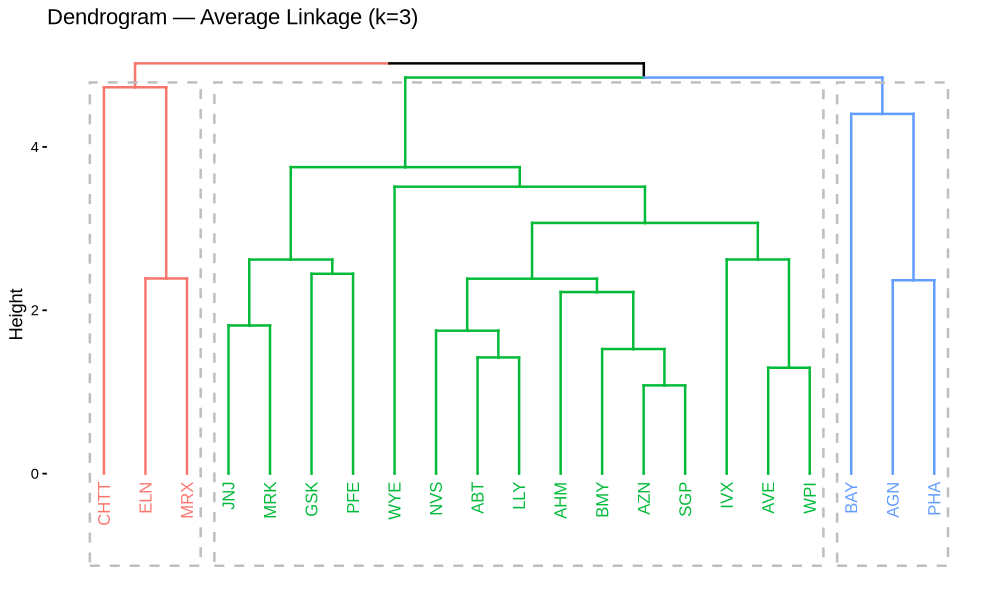

In [5]:
tmp_file <- tempfile(fileext = ".png")
png(tmp_file, width = 1000, height = 600, res = 120,
    type = "cairo", family = "sans")



print(
  factoextra::fviz_dend(hc_pharma, k = 3,
                        cex = 0.7,
                        color_labels_by_k = TRUE,
                        rect = TRUE,
                        main = "Dendrogram — Average Linkage (k=3)")
)

dev.off()
IRdisplay::display_png(file = tmp_file)

### Step 7 — Cut the Tree at k = 3 (Output Y)

Store the cluster labels in `Y_pharma_cluster`.

In [6]:


Y_pharma_cluster <- cutree(hc_pharma, k = 3)

cat("Cluster sizes:\n"); print(table(Y_pharma_cluster))
cat("\nFirm membership:\n"); print(sort(Y_pharma_cluster))

Cluster sizes:
Y_pharma_cluster
 1  2  3 
15  3  3 

Firm membership:
 ABT  AHM  AZN  AVE  BMY  LLY  GSK  IVX  JNJ  MRK  NVS  PFE  SGP  WPI  WYE  AGN 
   1    1    1    1    1    1    1    1    1    1    1    1    1    1    1    2 
 BAY  PHA CHTT  ELN  MRX 
   2    2    3    3    3 


### Step 8 — Cluster Centroid Profiles (Original Scale)

Store the centroid summary table in `pharma_profile`.

In [7]:

pharma_profile <- aggregate(X_pharma, by = list(Cluster = Y_pharma_cluster), FUN = mean)
pharma_profile

Cluster,Market_Cap,Beta,PE_Ratio,ROE,ROA,Asset_Turnover,Leverage,Rev_Growth,Net_Profit_Margin
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,75.1713333,0.4293333,20.64000,30.73333,12.893333,0.76,0.3893333,12.589333,18.140000
2,26.9066667,0.6400000,55.63333,10.10000,4.200000,0.70,0.3166667,6.996667,5.133333
3,0.7966667,0.8933333,19.40000,16.80000,4.933333,0.40,1.8366667,23.653333,14.033333


### Question 1 — Analysis Answer

*Your answer here* — In 3–6 sentences, describe:
- How many firms ended up in each cluster
- A short profile/label for each cluster (e.g., "large stable leaders", "small high-leverage outliers")
- One business takeaway an investor or analyst could use

Cluster 1 ended up with 15 firms, and cluster 2 and 3 ended up with three firms each. Cluster 1 represents the largest firms with high market caps
and strong margins. Cluster 2 is more mid-size firms with slightly weaker profitability. Cluster 3 is the smallest firms that have the most thin
returns. Investors would note that cluster 3 is the most risky to invest in, whereas cluster 1 is the most stable.




---

## Question 2 — Linear Discriminant Analysis (LDA) on System Administrators

**Dataset:** `mlba::SystemAdministrators` (75 observations × 3 variables)

**Inputs (X):** `Experience` (years), `Training` (number of credits)

**Output (Y):** `Completed.task` — categorical with two levels: `"Yes"` / `"No"` (whether the administrator completed a complex task within a fixed time)

**Tasks:**
1. Load data into `admin.df`; create `X_admin` (the two predictors) and `Y_admin` (the factor target). Confirm class balance.
2. Build an LDA model `Completed.task ~ Experience + Training` → store in `lda_admin`
3. Report the linear discriminant coefficients (the LD1 direction)
4. Predict the class for every observation → store predicted classes in `Y_admin_pred`; produce a confusion matrix `cm_admin` and overall accuracy `accuracy_admin`
5. Predict the class and posterior probabilities for a new administrator with `Experience = 8`, `Training = 6` (use `new_admin` and `pred_new`)
6. Provide a written interpretation in the **markdown answer cell** at the end of this question

### Step 1 — Load Data and Inspect Class Balance

In [8]:

admin.df <- mlba::SystemAdministrators
admin.df$Completed.task <- factor(admin.df$Completed.task, levels = c("No", "Yes"))
X_admin  <- admin.df[, c("Experience", "Training")]
Y_admin  <- admin.df$Completed.task

cat("Sample size:", nrow(admin.df), "\n")
cat("Class balance:\n"); print(table(Y_admin))

Sample size: 75 
Class balance:
Y_admin
 No Yes 
 60  15 


### Step 2 — Build the LDA Model

Store the fitted model in `lda_admin`.

In [9]:


lda_admin <- MASS::lda(Completed.task ~ Experience + Training, data = admin.df)
lda_admin

Call:
lda(Completed.task ~ Experience + Training, data = admin.df)

Prior probabilities of groups:
 No Yes 
0.8 0.2 

Group means:
    Experience Training
No    6.013333 4.500000
Yes   9.946667 5.066667

Coefficients of linear discriminants:
                  LD1
Experience 0.60173656
Training   0.06009381

### Step 3 — Linear Discriminant Coefficients

In [10]:


lda_admin$scaling

,LD1
Experience,0.60173656
Training,0.06009381


### Step 4 — Confusion Matrix on Training Data

Store predicted classes in `Y_admin_pred`, the confusion matrix in `cm_admin`, and accuracy in `accuracy_admin`.

In [11]:


pred_admin     <- predict(lda_admin, admin.df)
Y_admin_pred   <- pred_admin$class
cm_admin       <- table(Predicted = Y_admin_pred, Actual = Y_admin)
accuracy_admin <- sum(diag(cm_admin)) / sum(cm_admin)

cm_admin
cat("Overall accuracy:", round(accuracy_admin, 4), "\n")

         Actual
Predicted No Yes
      No  58   5
      Yes  2  10

Overall accuracy: 0.9067 


### Step 5 — Predict for a New Administrator (Experience = 8, Training = 6)

Store the new observation in `new_admin` and the prediction in `pred_new`.

In [12]:


new_admin <- data.frame(Experience = 8, Training = 6)
pred_new  <- predict(lda_admin, new_admin)

cat("Predicted class:", as.character(pred_new$class), "\n")
cat("Posterior probabilities:\n"); print(round(pred_new$posterior, 4))

Predicted class: No 
Posterior probabilities:
      No    Yes
1 0.7653 0.2347


### Question 2 — Analysis Answer

*Your answer here* — In 3–6 sentences, address:
- Class balance and what it implies about accuracy as a metric
- Which predictor (`Experience` or `Training`) drives more of the LD1 separation, and the sign of the effect
- Interpretation of the predicted class and posterior probability for the new administrator (Experience = 8, Training = 6)
- One business/management takeaway

The class balance is skewed towards no, which means accuracy isnt the most reliable metric. Experience crushes Training in the LD1 seperation,
which means that experience is the driving factor in people that complete or dont complete tasks. The new administrator is predicted to no complete
the task with a 76.5% posterior chance of no. This shows that management should prioritize experienced hires when needing someone to complete a hard task.


---

## Question 3 — K-Means Clustering on Breakfast Cereals

**Dataset:** `mlba::Cereals` (77 cereals × 16 variables)

**Inputs (X):** 8 numeric nutrition variables — `calories`, `protein`, `fat`, `sodium`, `fiber`, `carbo`, `sugars`, `potass`

**Output (Y):** Cluster label for each cereal from **k-means with k = 4** on standardized inputs.

**Tasks:**
1. Load `mlba::Cereals`, drop rows with `NA` in the input variables, set `name` as row label → store in `cereals_clean`
2. Standardize the 8 inputs → store in `X_cereals_norm`
3. Use the **elbow method** (`fviz_nbclust`) to inspect WSS for k = 1..10
4. Run k-means with `k = 4`, `nstart = 25`, `set.seed(123)` → store in `km_cereals`; store labels in `Y_cereals_cluster`
5. Report cluster sizes and centroid profiles → store profile table in `cereals_profile`
6. Plot the cluster visualization (`fviz_cluster`)
7. Provide a written interpretation in the **markdown answer cell** at the end of this question

### Step 1 — Load Data and Select Inputs (X)

Use `cereals.df` for the raw data, `input_vars` for the 8 variable names, and `cereals_clean` for the cleaned dataframe with `name` as row label.

In [13]:


cereals.df <- mlba::Cereals

input_vars <- c("calories", "protein", "fat", "sodium",
                "fiber", "carbo", "sugars", "potass")

cereals_clean <- cereals.df[complete.cases(cereals.df[, input_vars]), ]
rownames(cereals_clean) <- cereals_clean$name

cat("Cereals retained after dropping NAs:", nrow(cereals_clean), "\n")
head(cereals_clean)

Cereals retained after dropping NAs: 74 


,name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>
100%_Bran,100%_Bran,N,C,70,4,1,130,10.0,5.0,6,280,25,3,1,0.33,68.40297
100%_Natural_Bran,100%_Natural_Bran,Q,C,120,3,5,15,2.0,8.0,8,135,0,3,1,1.00,33.98368
All-Bran,All-Bran,K,C,70,4,1,260,9.0,7.0,5,320,25,3,1,0.33,59.42551
All-Bran_with_Extra_Fiber,All-Bran_with_Extra_Fiber,K,C,50,4,0,140,14.0,8.0,0,330,25,3,1,0.50,93.70491
Apple_Cinnamon_Cheerios,Apple_Cinnamon_Cheerios,G,C,110,2,2,180,1.5,10.5,10,70,25,1,1,0.75,29.50954
Apple_Jacks,Apple_Jacks,K,C,110,2,0,125,1.0,11.0,14,30,25,2,1,1.00,33.17409


### Step 2 — Standardize the Inputs

Store the standardized matrix in `X_cereals_norm`.

In [14]:


X_cereals_norm <- scale(cereals_clean[, input_vars])

round(colMeans(X_cereals_norm), 4)
round(apply(X_cereals_norm, 2, sd), 4)

calories  protein      fat   sodium    fiber    carbo   sugars   potass 
       0        0        0        0        0        0        0        0

calories  protein      fat   sodium    fiber    carbo   sugars   potass 
       1        1        1        1        1        1        1        1

### Step 3 — Elbow Method

Use `fviz_nbclust(X_cereals_norm, kmeans, method = "wss", k.max = 10)`.

agg_record_261764320 
                   2

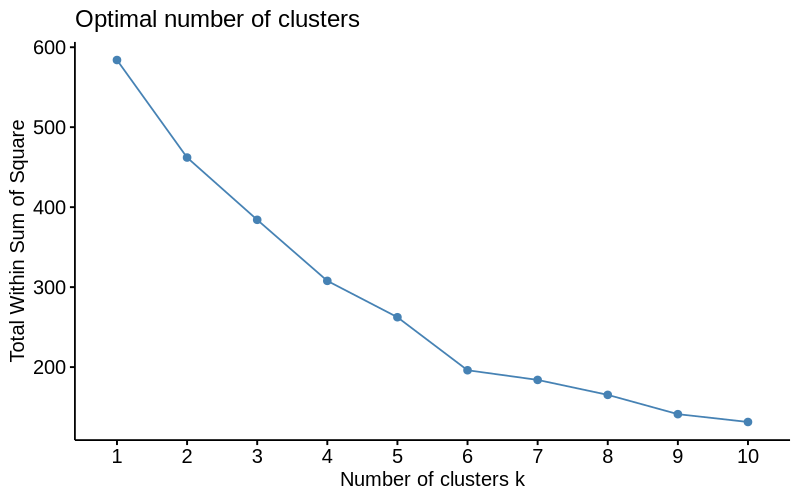

In [15]:
tmp_file <- tempfile(fileext = ".png")
png(tmp_file, width = 800, height = 500, res = 120,
    type = "cairo", family = "sans")

set.seed(123)


print(
  factoextra::fviz_nbclust(X_cereals_norm, kmeans, method = "wss", k.max = 10)
)

dev.off()
IRdisplay::display_png(file = tmp_file)

### Step 4 — Run K-Means with k = 4 (Output Y)

Store the k-means object in `km_cereals` and the labels in `Y_cereals_cluster`.

In [16]:
set.seed(123)


km_cereals        <- kmeans(X_cereals_norm, centers = 4, nstart = 25)
Y_cereals_cluster <- km_cereals$cluster

cat("Cluster sizes:\n"); print(km_cereals$size)
cat("\nTotal within-cluster SS:", round(km_cereals$tot.withinss, 2), "\n")

Cluster sizes:
[1] 31 19  3 21

Total within-cluster SS: 287.77 


### Step 5 — Cluster Centroid Profiles (Standardized Scale)

In [17]:


round(km_cereals$centers, 2)

,calories,protein,fat,sodium,fiber,carbo,sugars,potass
1,-0.50,0.03,-0.61,-0.08,-0.15,0.67,-0.88,-0.27
2,0.95,0.75,1.05,0.02,0.41,-0.12,0.45,0.77
3,-2.20,1.38,-0.33,0.17,3.64,-2.07,-0.79,2.98
4,0.20,-0.92,0.00,0.07,-0.66,-0.59,1.00,-0.72


### Step 6 — Cluster Profiles & Visualization

Build a profile table `cereals_profile` (one row per cluster, with `n` and the mean of each input variable on the **original** scale), then plot `fviz_cluster`.

  Cluster  calories  protein       fat   sodium      fiber     carbo    sugars
1       1  97.09677 2.548387 0.3870968 155.8065  1.8064516 17.354839  3.290323
2       2 125.78947 3.315789 2.0526316 163.9474  3.1578947 14.263158  9.052632
3       3  63.33333 4.000000 0.6666667 176.6667 11.0000000  6.666667  3.666667
4       4 110.95238 1.523810 1.0000000 168.5714  0.5714286 12.428571 11.476190
     potass  n
1  79.35484 31
2 152.89474 19
3 310.00000  3
4  47.38095 21


agg_record_2003724327 
                    2

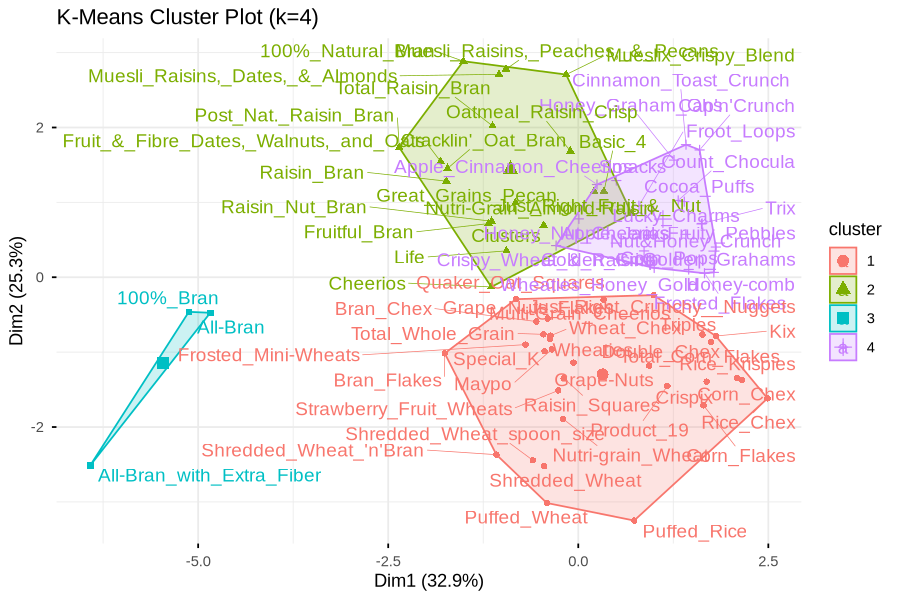

In [18]:


cereals_profile <- aggregate(cereals_clean[, input_vars],
                             by = list(Cluster = Y_cereals_cluster),
                             FUN = mean)
cereals_profile$n <- km_cereals$size
print(cereals_profile)

tmp_file <- tempfile(fileext = ".png")
png(tmp_file, width = 900, height = 600, res = 120,
    type = "cairo", family = "sans")

print(
  factoextra::fviz_cluster(km_cereals, data = X_cereals_norm,
                           ellipse.type = "convex",
                           repel = TRUE,
                           ggtheme = ggplot2::theme_minimal(),
                           main = "K-Means Cluster Plot (k=4)")
)
dev.off()
IRdisplay::display_png(file = tmp_file)

### Question 3 — Analysis Answer

*Your answer here* — In 3–6 sentences, address:
- Where the elbow occurs and why k = 4 is reasonable
- A short profile/label for each of the 4 clusters (e.g., "high-fiber health cereals", "sugary kids' cereals")
- One business takeaway for a cereal manufacturer or grocery merchandiser

The elbow occurs around 4-5 clusters which makes k=4 reasonable. Cluster 1, which has 31 cereals, is the average middle of the road nutrition wise
cereals that most people eat every day. Cluster 2, which has 19 cereals, are the high calorie, high fat cereals for people that like rich flavors. Cluster 3,
which has three cereals, are the healthy high fiber, low calorie options. Lastly, Cluster 4, which has 21 cereals, are the high sugar, low fiber cereals that most 
kids go crazy for.

---

## Submission Checklist

Before submitting, verify that:

- [ ] All `# YOUR CODE HERE — delete this comment when you add your code` comments have been **removed**
- [ ] All `NULL` placeholders have been **replaced** with working code
- [ ] The notebook **runs top-to-bottom without errors** (Kernel → Restart & Run All)
- [ ] All three `*Your answer here*` markdown cells have been replaced with your written interpretation
- [ ] Variable names match the required names in the table at the top of the notebook